# 🛰️ Notebook 1: Introduction to STAC
This notebook introduces the **SpatioTemporal Asset Catalog (STAC)** — an open standard for describing and sharing geospatial data.

By the end of this notebook, you will:
- Understand the purpose of STAC
- Learn its key components (Collection, Item, Asset)
- Explore an online STAC Catalog using Python and `pystac-client`

## 🧩 STAC Core Concepts
| Concept | Description |
|----------|--------------|
| **Catalog** | Root-level structure that links multiple collections |
| **Collection** | A group of related Items (e.g., Sentinel-2 L2A) |
| **Item** | Represents a single spatiotemporal asset (e.g., one image tile) |
| **Asset** | The actual data files (e.g., bands, metadata) |
| **Extension** | Extra metadata like EO, SAR, or Projection info |

📚 Learn more: [https://stacspec.org](https://stacspec.org)

In [ ]:
from pystac_client import Client

# Connect to a public catalog
catalog = Client.open('https://earth-search.aws.element84.com/v1')

# How many total collections ? 
print(f'We have total - {len(list(catalog.get_all_collections()))} in this catalog')
# Print root collections
for collection in catalog.get_collections():
    print(collection.id, '-', collection.description)

We have total - 9 in this catalog
sentinel-2-pre-c1-l2a - Sentinel-2 Pre-Collection 1 Level-2A (baseline < 05.00), with data and metadata matching collection sentinel-2-c1-l2a
cop-dem-glo-30 - The Copernicus DEM is a Digital Surface Model (DSM) which represents the surface of the Earth including buildings, infrastructure and vegetation. GLO-30 Public provides limited worldwide coverage at 30 meters because a small subset of tiles covering specific countries are not yet released to the public by the Copernicus Programme.
naip - The [National Agriculture Imagery Program](https://www.fsa.usda.gov/programs-and-services/aerial-photography/imagery-programs/naip-imagery/) (NAIP) provides U.S.-wide, high-resolution aerial imagery, with four spectral bands (R, G, B, IR).  NAIP is administered by the [Aerial Field Photography Office](https://www.fsa.usda.gov/programs-and-services/aerial-photography/) (AFPO) within the [US Department of Agriculture](https://www.usda.gov/) (USDA).  Data are captur

In [38]:
from pystac_client import Client

# Connect to a public catalog
catalog = Client.open('https://stac.dataspace.copernicus.eu/v1')

# How many total collections ? 
print(f'We have total - {len(list(catalog.get_all_collections()))} in this catalog')

# Print root collections
for collection in catalog.get_collections():
    print(collection.id, '-', collection.description)

We have total - 137 in this catalog
sentinel-3-sl-2-aod-nrt - The Copernicus Sentinel-3 SLSTR AOD product quantifies the abundance of aerosol particles, and monitors their global distribution & long-range transport, at the scale of 9.5 x 9.5 km2. All observations are made available in less than 3 hours from the SLSTR observation sensing time.
sentinel-1-global-mosaics - Sentinel-1 monthly mosaics are generated from monthly stacks of Sentinel-1 GRD data by calculating the weighted sum of the terrain corrected backscatter observations. Two different Sentinel-1 mosaics are being produced for each month: IW mosaic and DH mosaic.
sentinel-3-olci-2-wfr-nrt - This collection provides Sentinel-3 OLCI Level-2 Water Full Resolution products containing data on water-leaving reflectance, ocean color, and more.
cop-dem-glo-30-dged-cog - This Collection provides Copernicus DEM COG products, which represent the surface of the Earth including buildings, infrastructure and vegetation, in resolution of 

### Exercise : 
Can you find out total collections available in 

1. https://planetarycomputer.microsoft.com/api/stac/v1/
2. https://nz-elevation.s3-ap-southeast-2.amazonaws.com/catalog.json
3. https://explorer.sandbox.dea.ga.gov.au/stac/

## STAC Search

### Goals
- Understand STAC concepts (Catalog, Collection, Item, Asset)
- Use `pystac-client` to query public STAC endpoints
- Visualize footprints with `folium`

#### Quick start: imports and environment check

In [14]:
from pystac_client import Client
import folium

print('Imports OK')

Imports OK


#### Connect to a STAC endpoint and search
We connect to the Element84 Earth Search STAC and demonstrate a bbox / datetime / cloud filter search.


In [16]:
catalog = Client.open('https://earth-search.aws.element84.com/v1')
print('Catalog title:', catalog.title)

bbox = [166.509144322, -46.641235447, 178.517093541, -34.4506617165]
search = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=bbox,
    datetime='2024-01-01/2024-01-31',
    query={"eo:cloud_cover": {"lt": 20}},
    # limit=10
)
items = list(search.get_items())
print(f'Found {len(items)} items')


Catalog title: Earth Search by Element 84
Found 295 items


Get all scenes as dataframe to visualise better

In [17]:
import pandas as pd
scenes_df  = pd.DataFrame([item.to_dict() for item in items])
scenes_df

,type,stac_version,stac_extensions,id,geometry,bbox,properties,links,assets,collection
0,Feature,1.1.0,[https://stac-extensions.github.io/raster/v1.1...,S2A_59GLL_20240131_0_L2A,"{'type': 'Polygon', 'coordinates': [[[168.4959...","[168.45297835152306, -45.23554223449076, 169.8...","{'created': '2024-02-01T02:29:42.498Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
1,Feature,1.1.0,[https://stac-extensions.github.io/view/v1.0.0...,S2A_59GML_20240131_0_L2A,"{'type': 'Polygon', 'coordinates': [[[169.7470...","[169.72553232689162, -45.24028835526346, 171.1...","{'created': '2024-02-01T02:22:27.240Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
2,Feature,1.1.0,[https://stac-extensions.github.io/view/v1.0.0...,S2A_58GGT_20240131_0_L2A,"{'type': 'Polygon', 'coordinates': [[[168.2877...","[167.90174613219182, -43.40407972332248, 168.8...","{'created': '2024-02-01T02:25:41.699Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
3,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2A_59GKP_20240131_1_L2A,"{'type': 'Polygon', 'coordinates': [[[168.6181...","[168.24881990616686, -42.516817666303744, 168....","{'created': '2024-02-01T02:22:29.301Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
4,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2A_58GGU_20240131_1_L2A,"{'type': 'Polygon', 'coordinates': [[[168.6302...","[168.25375909869885, -42.494005014959136, 168....","{'created': '2024-02-01T02:19:58.919Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
...,...,...,...,...,...,...,...,...,...,...
290,Feature,1.1.0,[https://stac-extensions.github.io/projection/...,S2A_59GNM_20240101_0_L2A,"{'type': 'Polygon', 'coordinates': [[[170.9997...","[170.9997616481745, -44.340557984995506, 171.7...","{'created': '2024-01-02T02:20:08.793Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
291,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2A_59GPP_20240101_0_L2A,"{'type': 'Polygon', 'coordinates': [[[172.1989...","[172.19897178512224, -41.83792697631322, 172.2...","{'created': '2024-01-02T01:09:18.616Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
292,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2A_59HMV_20240101_0_L2A,"{'type': 'Polygon', 'coordinates': [[[170.9528...","[170.9528795501342, -36.17049658883871, 171.10...","{'created': '2024-01-02T01:35:05.484Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a
293,Feature,1.1.0,[https://stac-extensions.github.io/raster/v1.1...,S2A_59HPA_20240101_0_L2A,"{'type': 'Polygon', 'coordinates': [[[172.0990...","[172.09905192261127, -36.22788818051636, 173.3...","{'created': '2024-01-02T01:45:50.120Z', 'platf...","[{'rel': 'self', 'href': 'https://earth-search...",{'aot': {'href': 'https://sentinel-cogs.s3.us-...,sentinel-2-l2a


Use Geometry to convert this into GeoDataFrame

In [24]:
# Get scenes as gdf

import geopandas as gpd

gdf = gpd.GeoDataFrame.from_features(items, crs="epsg:4326")
gdf.head()

,geometry,created,platform,constellation,instruments,eo:cloud_cover,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,grid:code,...,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,earthsearch:boa_offset_applied,processing:software,updated,proj:code
0,"POLYGON ((168.49596 -44.22543, 168.45298 -45.2...",2024-02-01T02:29:42.498Z,sentinel-2a,sentinel-2,[msi],12.325381,59,G,LL,MGRS-59GLL,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:38:35.680000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/L...,roda-sentinel2/workflow-sentinel2-to-stac/bc8f...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:29:42.498Z,EPSG:32759
1,"POLYGON ((169.74704 -44.24601, 169.72553 -45.2...",2024-02-01T02:22:27.240Z,sentinel-2a,sentinel-2,[msi],14.431089,59,G,ML,MGRS-59GML,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:38:31.957000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/M...,roda-sentinel2/workflow-sentinel2-to-stac/13f8...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:22:27.240Z,EPSG:32759
2,"POLYGON ((168.28777 -42.40499, 167.90175 -43.4...",2024-02-01T02:25:41.699Z,sentinel-2a,sentinel-2,[msi],18.955699,58,G,GT,MGRS-58GGT,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:38:09.300000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/58/G/G...,roda-sentinel2/workflow-sentinel2-to-stac/81c0...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:25:41.699Z,EPSG:32758
3,"POLYGON ((168.61818 -41.52664, 168.61664 -41.5...",2024-02-01T02:22:29.301Z,sentinel-2a,sentinel-2,[msi],1.033786,59,G,KP,MGRS-59GKP,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:37:56.400000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/K...,roda-sentinel2/workflow-sentinel2-to-stac/846d...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:22:29.301Z,EPSG:32759
4,"POLYGON ((168.63022 -41.49398, 168.62955 -41.4...",2024-02-01T02:19:58.919Z,sentinel-2a,sentinel-2,[msi],2.007665,58,G,GU,MGRS-58GGU,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:37:56.002000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/58/G/G...,roda-sentinel2/workflow-sentinel2-to-stac/80e6...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:19:58.919Z,EPSG:32758


Let's plot few footprints

<Axes: >

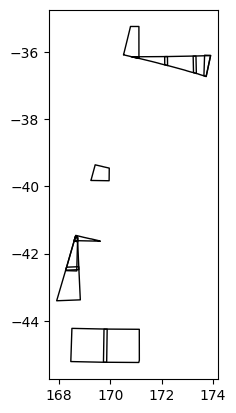

In [23]:
gdf.head(15).plot(facecolor="none",edgecolor="black")

Let's print all footprints on interactive map

In [28]:
gdf = gpd.GeoDataFrame.from_features(items, crs="epsg:4326")
# Create folium map
m = folium.Map(location=[-36,174], zoom_start=5)

# Add GeoPandas layer to folium
folium.GeoJson(
    gdf,
    name="Footprints"
).add_to(m)

m

Let's color these footprints based on `cloud_cover`

In [ ]:

# Function to map cloud cover to a color
def cloud_to_color(cloud):
    if cloud is None:
        return "#cccccc"  # grey for missing values
    if cloud < 10:
        return "#2ecc71"  # green
    elif cloud < 30:
        return "#f1c40f"  # yellow
    elif cloud < 60:
        return "#e67e22"  # orange
    else:
        return "#e74c3c"  # red

# Create folium map
m = folium.Map(location=[-36,174], zoom_start=5)

# Add polygons with style based on cloud cover
folium.GeoJson(
    gdf,
    name="Footprints",
    style_function=lambda feature: {
        "fillColor": cloud_to_color(feature["properties"].get("eo:cloud_cover")),
        "color": "black",     # polygon boundary
        "weight": 1,
        "fillOpacity": 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["eo:cloud_cover"],
        aliases=["Cloud cover:"]
    )
).add_to(m)

m


Let's see what all properties are available in each item

In [25]:
scenes_props_df  = pd.DataFrame([item.to_dict()['properties'] for item in items])
scenes_props_df

,created,platform,constellation,instruments,eo:cloud_cover,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,grid:code,view:sun_azimuth,...,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,earthsearch:boa_offset_applied,processing:software,updated,proj:code
0,2024-02-01T02:29:42.498Z,sentinel-2a,sentinel-2,[msi],12.325381,59,G,LL,MGRS-59GLL,57.701975,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:38:35.680000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/L...,roda-sentinel2/workflow-sentinel2-to-stac/bc8f...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:29:42.498Z,EPSG:32759
1,2024-02-01T02:22:27.240Z,sentinel-2a,sentinel-2,[msi],14.431089,59,G,ML,MGRS-59GML,56.219718,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:38:31.957000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/M...,roda-sentinel2/workflow-sentinel2-to-stac/13f8...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:22:27.240Z,EPSG:32759
2,2024-02-01T02:25:41.699Z,sentinel-2a,sentinel-2,[msi],18.955699,58,G,GT,MGRS-58GGT,60.911375,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:38:09.300000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/58/G/G...,roda-sentinel2/workflow-sentinel2-to-stac/81c0...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:25:41.699Z,EPSG:32758
3,2024-02-01T02:22:29.301Z,sentinel-2a,sentinel-2,[msi],1.033786,59,G,KP,MGRS-59GKP,62.025185,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:37:56.400000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/K...,roda-sentinel2/workflow-sentinel2-to-stac/846d...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:22:29.301Z,EPSG:32759
4,2024-02-01T02:19:58.919Z,sentinel-2a,sentinel-2,[msi],2.007665,58,G,GU,MGRS-58GGU,61.988234,...,S2A_OPER_MSI_L2A_TL_2APS_20240201T003653_A0449...,1.031336,2024-01-31T22:37:56.002000Z,1,s3://sentinel-cogs/sentinel-s2-l2a-cogs/58/G/G...,roda-sentinel2/workflow-sentinel2-to-stac/80e6...,True,{'sentinel2-to-stac': '0.1.1'},2024-02-01T02:19:58.919Z,EPSG:32758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,2024-01-02T02:20:08.793Z,sentinel-2a,sentinel-2,[msi],9.485817,59,G,NM,MGRS-59GNM,59.062545,...,S2A_OPER_MSI_L2A_TL_2APS_20240102T004450_A0445...,1.034140,2024-01-01T22:38:15.188000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/N...,roda-sentinel2/workflow-sentinel2-to-stac/8d10...,True,{'sentinel2-to-stac': '0.1.1'},2024-01-02T02:20:08.793Z,EPSG:32759
291,2024-01-02T01:09:18.616Z,sentinel-2a,sentinel-2,[msi],14.965107,59,G,PP,MGRS-59GPP,60.284094,...,S2A_OPER_MSI_L2A_TL_2APS_20240102T000649_A0445...,1.034140,2024-01-01T22:37:36.701000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/G/P...,roda-sentinel2/workflow-sentinel2-to-stac/3cbe...,True,{'sentinel2-to-stac': '0.1.1'},2024-01-02T01:09:18.616Z,EPSG:32759
292,2024-01-02T01:35:05.484Z,sentinel-2a,sentinel-2,[msi],0.000000,59,H,MV,MGRS-59HMV,71.909243,...,S2A_OPER_MSI_L2A_TL_2APS_20240102T000748_A0445...,1.034140,2024-01-01T22:36:13.190000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/H/M...,roda-sentinel2/workflow-sentinel2-to-stac/afae...,True,{'sentinel2-to-stac': '0.1.1'},2024-01-02T01:35:05.484Z,EPSG:32759
293,2024-01-02T01:45:50.120Z,sentinel-2a,sentinel-2,[msi],19.784506,59,H,PA,MGRS-59HPA,71.225639,...,S2A_OPER_MSI_L2A_TL_2APS_20240102T000748_A0445...,1.034140,2024-01-01T22:36:01.106000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/59/H/P...,roda-sentinel2/workflow-sentinel2-to-stac/b18c...,True,{'sentinel2-to-stac': '0.1.1'},2024-01-02T01:45:50.120Z,EPSG:32759


### Exercise : 

Can you make a footprint diagram based on 
1. view:sun_azimuth
2. platform

--- 

Let's Find out footprints based on custom geometry

In [31]:
# Intersects
area_of_interest =  {
        "coordinates": [
          [
            [
              174.55837760384964,
              -36.8139369892072
            ],
            [
              174.5599336206693,
              -36.81419109183735
            ],
            [
              174.56018134474095,
              -36.81335440926176
            ],
            [
              174.55947687941364,
              -36.81324904858582
            ],
            [
              174.55935301737787,
              -36.813664292763754
            ],
            [
              174.55849372450717,
              -36.81352794417733
            ],
            [
              174.55837760384964,
              -36.8139369892072
            ]
          ]
        ],
        "type": "Polygon"
      }

time_range = "2020-12-01/2020-12-31"

search = catalog.search(
    collections=["sentinel-2-l2a"], intersects=area_of_interest, datetime=time_range
)
items = list(search.get_items())
print(f'Found {len(items)} items')

/opt/homebrew/Caskroom/miniconda/base/envs/stac/lib/python3.12/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Found 12 items


Inspecting single element

In [33]:
item_0 = items[0]
item_0

<Item id=S2B_60HTE_20201229_1_L2A>

In [ ]:
item_0.assets['visual']

<Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/60/H/TE/2020/12/S2B_60HTE_20201229_1_L2A/TCI.tif>

In [35]:
from IPython.display import Image

Image(url=item_0.assets['thumbnail'].to_dict()['href'], width=500)

Let's use properties to filter the data

In [36]:
search = catalog.search(
    collections=["sentinel-2-l2a"], 
    intersects=area_of_interest, 
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": "10"}},
)
items = list(search.get_items())
print(f'Found {len(items)} items')

/opt/homebrew/Caskroom/miniconda/base/envs/stac/lib/python3.12/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Found 2 items


In [37]:
item_0 = items[0]
item_0
Image(url=item_0.assets['thumbnail'].to_dict()['href'], width=500)